# Hough Transforms and Planar Rectification

A self-contained walkthrough of **line and circle detection via the Hough transform**, plus **planar rectification** as a preprocessing step that makes Hough's job easier. The notebook builds up in three pieces: (1) standard and probabilistic Hough line detection on both synthetic and natural images (`cv2.HoughLines` / `cv2.HoughLinesP`); (2) Hough circle detection on a synthetic image and on `data.coins()` (`cv2.HoughCircles`); and (3) a mini-project that rectifies a planar object via `cv2.getPerspectiveTransform` + `cv2.warpPerspective` and shows that line detection on the rectified image produces cleaner, more concentrated `(rho, theta)` peaks than running it directly on the perspective view.


## 0. Setup

The notebook uses only standard scientific Python packages plus OpenCV, so it runs locally in Jupyter and also in Google Colab without any changes.

In [11]:
!pip -q install opencv-python-headless scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

def show_image(img, title='', cmap=None, figsize=(6, 6)):
    plt.figure(figsize=figsize)
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or 'gray')
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()


## Topic 1. Hough transform for line detection



The Hough transform detects lines by voting in a parameter space. A 2D line can be written as:

$$
\rho = x\cos\theta + y\sin\theta,
$$

where $\rho$ is the perpendicular distance from the origin to the line and $\theta$ is the angle of the line normal.

OpenCV provides:

- `cv2.HoughLines`: standard Hough transform.
- `cv2.HoughLinesP`: probabilistic Hough transform, returning finite line segments.

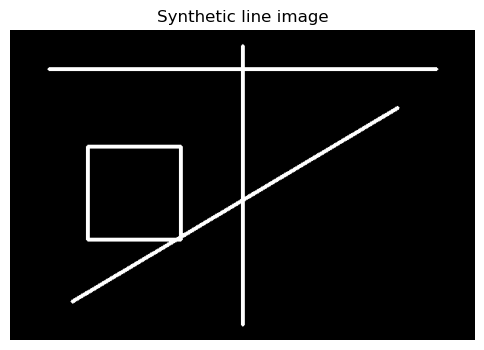

In [12]:
line_img = np.zeros((400, 600), dtype=np.uint8)
cv2.line(line_img, (50, 50), (550, 50), 255, 3)
cv2.line(line_img, (80, 350), (500, 100), 255, 3)
cv2.line(line_img, (300, 20), (300, 380), 255, 3)
cv2.rectangle(line_img, (100, 150), (220, 270), 255, 3)

show_image(line_img, 'Synthetic line image')


In [13]:
# 1. implement canny edge detection to extract edges from the line image
edges = cv2.Canny(line_img, 50, 150)


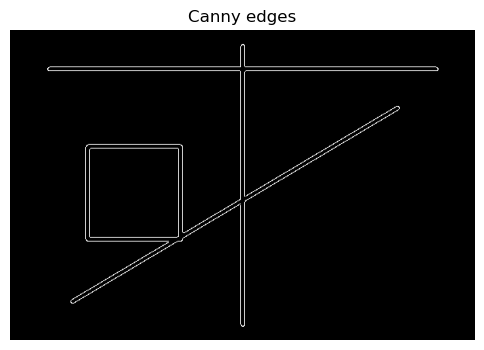

In [14]:
show_image(edges, 'Canny edges')

In [15]:
# 2. implement hough transformation for line detection
lines = cv2.HoughLines(edges, rho=1, theta=np.pi / 180, threshold=150)


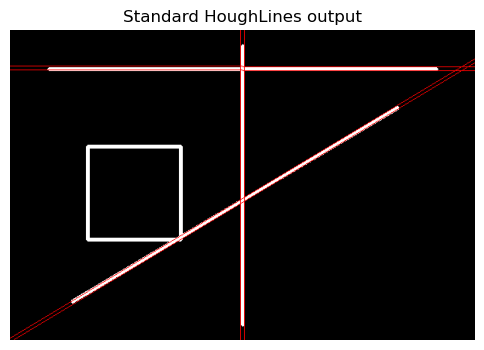

Number of detected standard lines: 6


In [16]:
output_standard = cv2.cvtColor(line_img, cv2.COLOR_GRAY2RGB)

if lines is not None:
    for line in lines[:20]:
        rho, theta = line[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a*rho, b*rho
        x1 = int(x0 + 1000*(-b)); y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b)); y2 = int(y0 - 1000*(a))
        cv2.line(output_standard, (x1, y1), (x2, y2), (255, 0, 0), 1)
show_image(output_standard, 'Standard HoughLines output')
print('Number of detected standard lines:', 0 if lines is None else len(lines))


In [17]:
# 3. implement the probabilistic hough transformation for line detection
lines_p = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=50,
    minLineLength=40,
    maxLineGap=10,
)


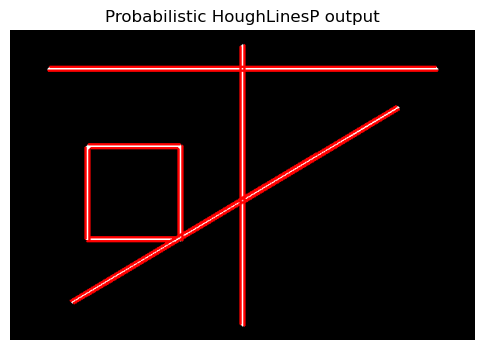

Number of detected line segments: 17


In [18]:

output_prob = cv2.cvtColor(line_img, cv2.COLOR_GRAY2RGB)

if lines_p is not None:
    for x1, y1, x2, y2 in lines_p[:, 0, :]:
        cv2.line(output_prob, (x1, y1), (x2, y2), (255, 0, 0), 2)
show_image(output_prob, 'Probabilistic HoughLinesP output')
print('Number of detected line segments:', 0 if lines_p is None else len(lines_p))


We now run line detection on a natural image. Hough methods usually work better after edge detection, thresholding, or region masking.

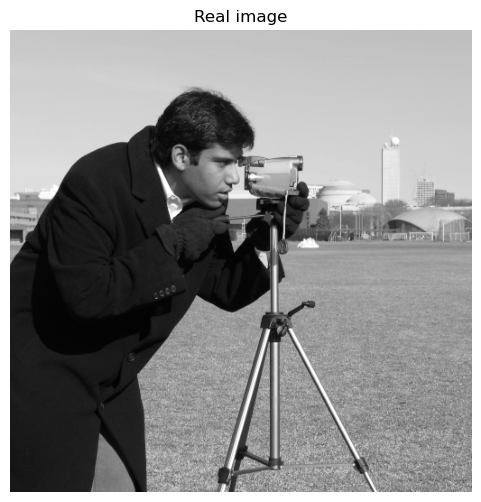

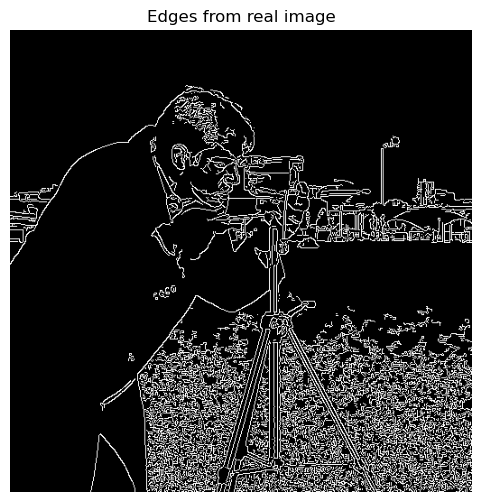

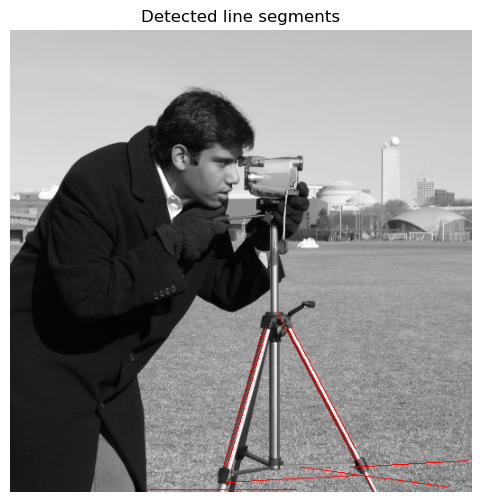

Number of detected line segments: 11


In [19]:
camera_img = data.camera()
small = cv2.resize(camera_img, (512, 512))
edges_real = cv2.Canny(small, 50, 150)
real_out = cv2.cvtColor(small, cv2.COLOR_GRAY2RGB)


lines_real = cv2.HoughLinesP(
    edges_real,
    rho=1,
    theta=np.pi / 180,
    threshold=120,
    minLineLength=120,
    maxLineGap=5,
)

if lines_real is not None:
    for x1, y1, x2, y2 in lines_real[:, 0, :]:
        cv2.line(real_out, (x1, y1), (x2, y2), (255, 0, 0), 1)
show_image(small, 'Real image')
show_image(edges_real, 'Edges from real image')
show_image(real_out, 'Detected line segments')
print('Number of detected line segments:', 0 if lines_real is None else len(lines_real))


## Topic 2. Hough circle transform

For circles, the parameter space is usually $(a,b,r)$, where $(a,b)$ is the circle centre and $r$ is the radius. OpenCV provides `cv2.HoughCircles`, which uses the Hough gradient method — edge points vote for `(cx, cy)` along the gradient direction, then radii are recovered from the accumulator peaks.

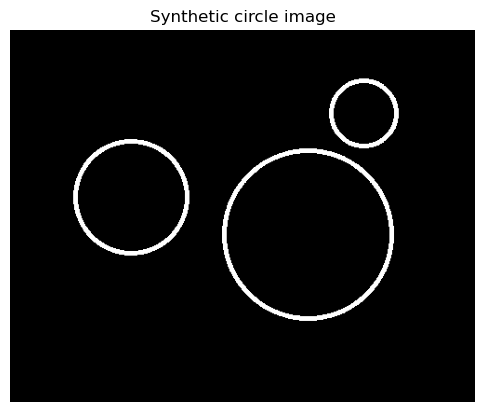

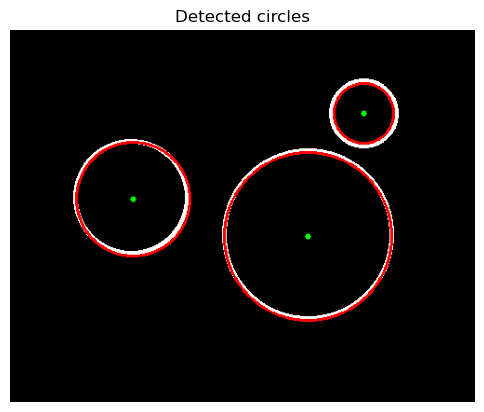

Detected circles [x, y, r]:
[[320 222  90]
 [132 182  61]
 [380  90  32]]


In [20]:
circle_img = np.zeros((400, 500), dtype=np.uint8)
cv2.circle(circle_img, (130, 180), 60, 255, 3)
cv2.circle(circle_img, (320, 220), 90, 255, 3)
cv2.circle(circle_img, (380, 90), 35, 255, 3)
blurred = cv2.medianBlur(circle_img, 5)

circles = cv2.HoughCircles(
    blurred,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=50,
    param1=100,
    param2=30,
    minRadius=20,
    maxRadius=120,
)
circle_out = cv2.cvtColor(circle_img, cv2.COLOR_GRAY2RGB)
if circles is not None:
    circles = np.round(circles[0]).astype(int)
    for x, y, r in circles:
        cv2.circle(circle_out, (x, y), r, (255, 0, 0), 2)
        cv2.circle(circle_out, (x, y), 3, (0, 255, 0), -1)
show_image(circle_img, 'Synthetic circle image')
show_image(circle_out, 'Detected circles')
print('Detected circles [x, y, r]:')
print(circles if circles is not None else 'None')


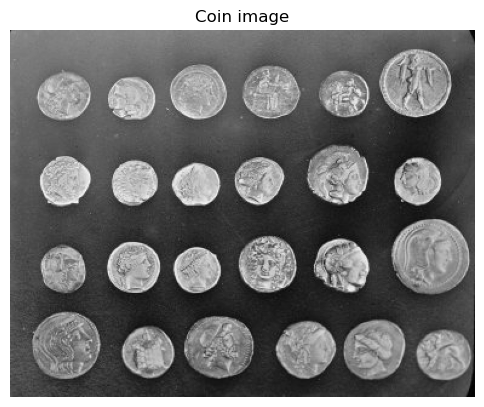

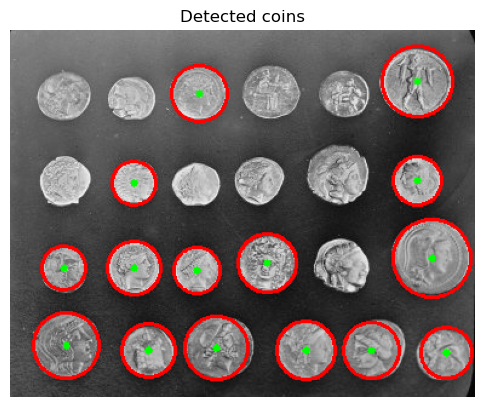

Detected coins [x, y, r]:
[[348 188  32]
 [ 46 260  27]
 [102 126  18]
 [212 192  24]
 [154 198  19]
 [336 124  20]
 [156  52  23]
 [102 196  22]
 [244 264  24]
 [ 44 196  18]
 [336  42  29]
 [114 264  22]
 [170 262  26]
 [298 264  23]
 [360 266  21]]


In [21]:
# apply this to coin images
coin_img = data.coins()
coin_blur = cv2.medianBlur(coin_img, 5)
coin_circles = cv2.HoughCircles(
    coin_blur,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=30,
    param1=80,
    param2=30,
    minRadius=18,
    maxRadius=35,
)
coin_out = cv2.cvtColor(coin_img, cv2.COLOR_GRAY2RGB)
if coin_circles is not None:
    coin_circles = np.round(coin_circles[0]).astype(int)
    for x, y, r in coin_circles:
        cv2.circle(coin_out, (x, y), r, (255, 0, 0), 2)
        cv2.circle(coin_out, (x, y), 3, (0, 255, 0), -1)
show_image(coin_img, 'Coin image')
show_image(coin_out, 'Detected coins')
print('Detected coins [x, y, r]:')
print(coin_circles if coin_circles is not None else 'None')

### Three things to know about `HoughCircles` parameters

1. Which parameter controls how strict the circle detection is?
2. What happens if the radius range is too wide?
3. What happens if `minDist` is too small?

**1. Which parameter controls how strict the circle detection is?**

`param2` — the accumulator threshold for the Hough gradient method. Each candidate `(cx, cy, r)` only survives if it accumulates more than `param2` edge-gradient votes, so raising `param2` rejects weakly-supported circles (fewer, more reliable detections) while lowering it admits more candidates (including spurious ones). `param1`, by contrast, just sets the upper Canny threshold used internally for edge detection.

**2. What happens if the radius range is too wide?**

Two things: (a) **runtime balloons** because the accumulator has to test many more radii at every candidate centre, and (b) **spurious detections** appear — short arcs in textured background regions accumulate enough votes at *some* radius in the wide range to be reported as circles, even when no real circle is present. A tight `minRadius`/`maxRadius` bracket around the expected object size both speeds detection up and suppresses these false positives.

**3. What happens if `minDist` is too small?**

The non-maximum suppression that keeps only the strongest peak in each neighbourhood stops working, so a *single* physical circle is reported multiple times as several near-duplicate detections with slightly different `(cx, cy, r)` values. Bumping `minDist` to roughly the smallest expected centre-to-centre separation (often the smallest expected diameter) collapses these duplicates back into one detection per object.


## Topic 3. Rectifying a plane and detecting lines

A short demonstration that **planar rectification** can make downstream line detection cleaner. The pipeline is:

1. Start from a perspective view of a planar object.
2. Identify the four corners of the object in the perspective view.
3. Estimate a homography that maps those four corners to a front-facing rectangle, and warp the image accordingly.
4. Run Canny edge detection on the rectified image, then `cv2.HoughLinesP` for line detection — and compare the result against running the same pipeline on the unrectified image.

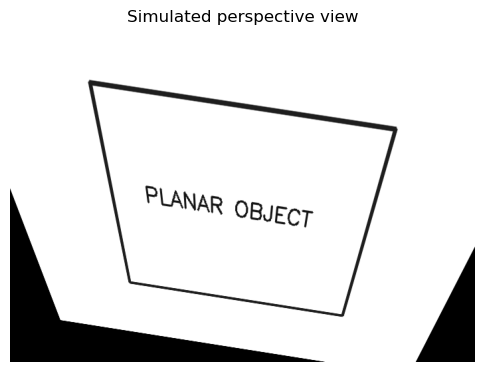

In [22]:
img_doc = np.ones((500, 700, 3), dtype=np.uint8) * 255
cv2.rectangle(img_doc, (160, 120), (540, 390), (30, 30, 30), 3)
cv2.putText(img_doc, 'PLANAR OBJECT', (210, 250), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (20, 20, 20), 2)

src_rect = np.float32([[160, 120], [540, 120], [540, 390], [160, 390]])
dst_quad = np.float32([[120, 80], [580, 150], [500, 430], [180, 380]])
H_sim = cv2.getPerspectiveTransform(src_rect, dst_quad)
perspective_view = cv2.warpPerspective(img_doc, H_sim, (700, 500))
show_image(perspective_view, 'Simulated perspective view')

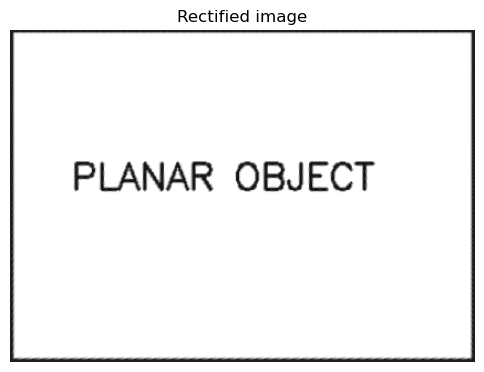

In [23]:
input_img = perspective_view.copy()
## define the rectified image size and target corner points
output_size = (420, 300)
target_points = np.float32([[0, 0], [output_size[0]-1, 0],
                            [output_size[0]-1, output_size[1]-1], [0, output_size[1]-1]])
## identify corner points in the perspective image
# reuse the known TL -> TR -> BR -> BL corners of the planar object
# in the perspective view (these are exactly `dst_quad` from the cell above)
corner_points = dst_quad
H = cv2.getPerspectiveTransform(corner_points, target_points)
rectified_project = cv2.warpPerspective(input_img, H, output_size)
show_image(rectified_project, 'Rectified image')


### Canny + Hough on the rectified image

The next cell runs Canny edge detection on the rectified grayscale and then `cv2.HoughLinesP` to recover line segments.

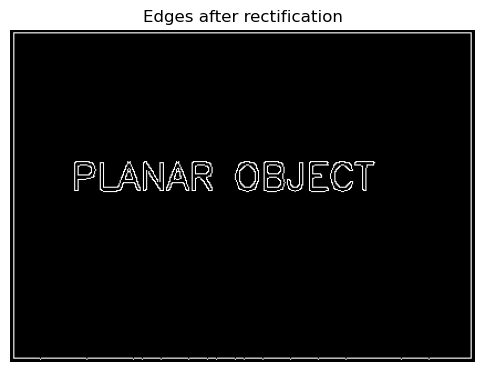

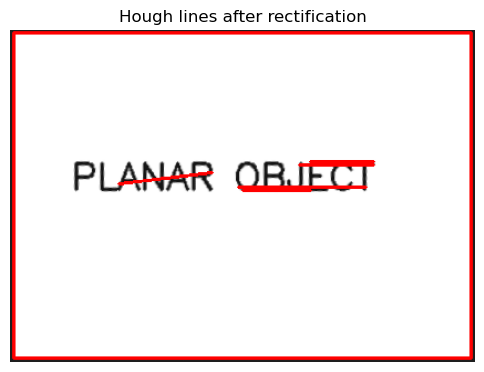

Number of detected line segments: 9


In [24]:
rectified_gray = cv2.cvtColor(rectified_project, cv2.COLOR_RGB2GRAY)
rectified_edges = cv2.Canny(rectified_gray, 50, 150)

project_lines = cv2.HoughLinesP(
    rectified_edges,
    rho=1,
    theta=np.pi / 180,
    threshold=60,
    minLineLength=40,
    maxLineGap=10,
)
project_out = rectified_project.copy()
if project_lines is not None:
    for x1, y1, x2, y2 in project_lines[:, 0, :]:
        cv2.line(project_out, (x1, y1), (x2, y2), (255, 0, 0), 2)

show_image(rectified_edges, 'Edges after rectification')
show_image(project_out, 'Hough lines after rectification')
print('Number of detected line segments:', 0 if project_lines is None else len(project_lines))

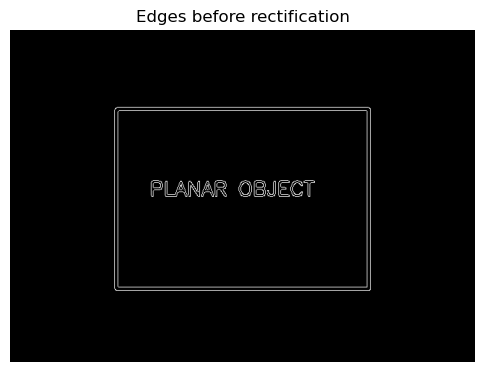

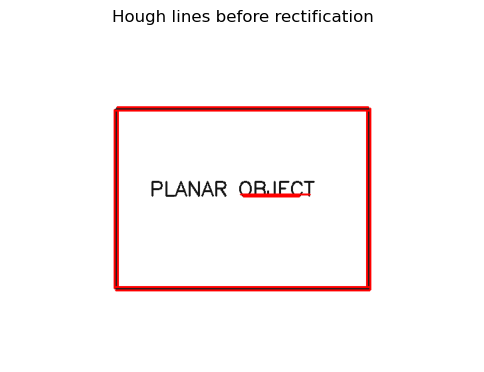

Number of detected line segments: 10


In [25]:
# Run line  detection on the original image.
out = img_doc.copy()
gray = cv2.cvtColor(img_doc, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(gray, 50, 150)

lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=80,
    minLineLength=40,
    maxLineGap=10,
)
if lines is not None:
    for x1, y1, x2, y2 in lines[:, 0, :]:
        cv2.line(out, (x1, y1), (x2, y2), (255, 0, 0), 2)

show_image(edges, 'Edges before rectification')
show_image(out, 'Hough lines before rectification')
print('Number of detected line segments:', 0 if lines is None else len(lines))


### Does rectification make line detection easier?

Yes — when we know in advance that the edges of interest are **axis-aligned in the object's own frame** (e.g. the rectangle border on a sheet of paper), rectifying the plane before running Hough is a big win even though straight 3D edges remain straight under perspective projection.

The reason is that the Hough accumulator votes in `(rho, theta)` bins. In a perspective view of a planar object, parallel object-frame edges no longer share a `theta` — they fan out toward the vanishing point — so their votes are scattered across many adjacent bins and the peaks are weaker. After rectification, those same edges are once again parallel and axis-aligned in the image, so all their votes pile into the same `theta` bin, producing taller, sharper peaks at well-defined angles (typically 0° and 90°).

Concretely you tend to see: fewer total detections but cleaner ones, the rectangle's four sides recovered as four full-length segments instead of a handful of disjoint fragments, and far less spurious noise from `HoughLinesP` because `minLineLength` can be set higher when edges aren't broken up by perspective foreshortening. The trade-off is that rectification itself requires knowing four corner correspondences, so if those have to be detected from the image, errors in the corner step propagate into every downstream line.
